# **Water Potablity Prediction**

## Import Libraries



In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [84]:
df = pd.read_csv('https://raw.githubusercontent.com/jadanpl/Water-Potability-Prediction/refs/heads/main/water_potability.csv')

In [85]:
df.shape

(3276, 10)

## Data Preprocessing

In [86]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [88]:
df.isnull().sum()

,0
ph,491
Hardness,0
Solids,0
Chloramines,0
Sulfate,781
Conductivity,0
Organic_carbon,0
Trihalomethanes,162
Turbidity,0
Potability,0


In [89]:
df.fillna(df.median(), inplace=True)

In [90]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000,3276.000000
mean,7.074194,196.369496,22014.092526,7.122277,333.608364,426.205111,14.284970,66.407478,3.966786,0.390110
std,1.470040,32.879761,8768.570828,1.583085,36.143851,80.824064,3.308162,15.769958,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.277673,176.850538,15666.690297,6.127421,317.094638,365.734414,12.065801,56.647656,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,7.870050,216.667456,27332.762127,8.114887,350.385756,481.792304,16.557652,76.666609,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


## Data Visualization

### Hisplot - visualize distribution of numerical features

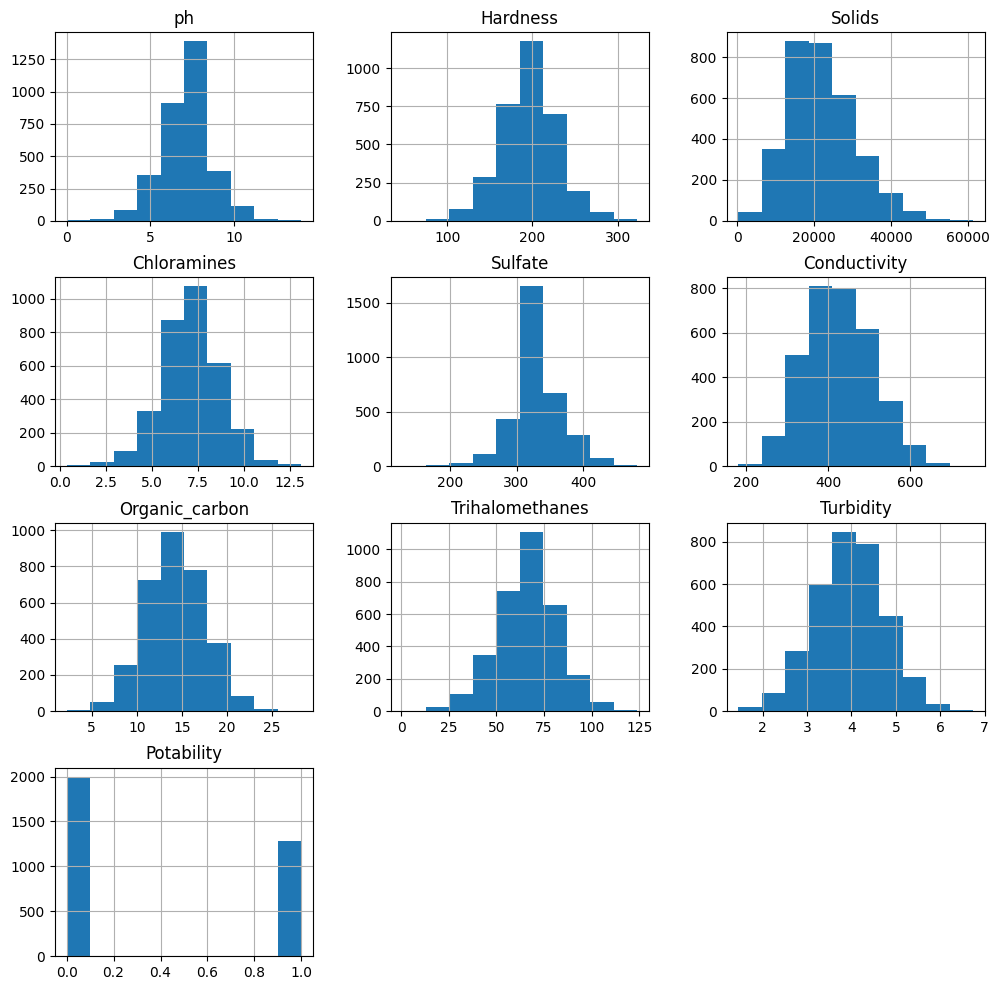

In [91]:
df.hist(figsize=(12,12))
plt.show()

### Pairplot

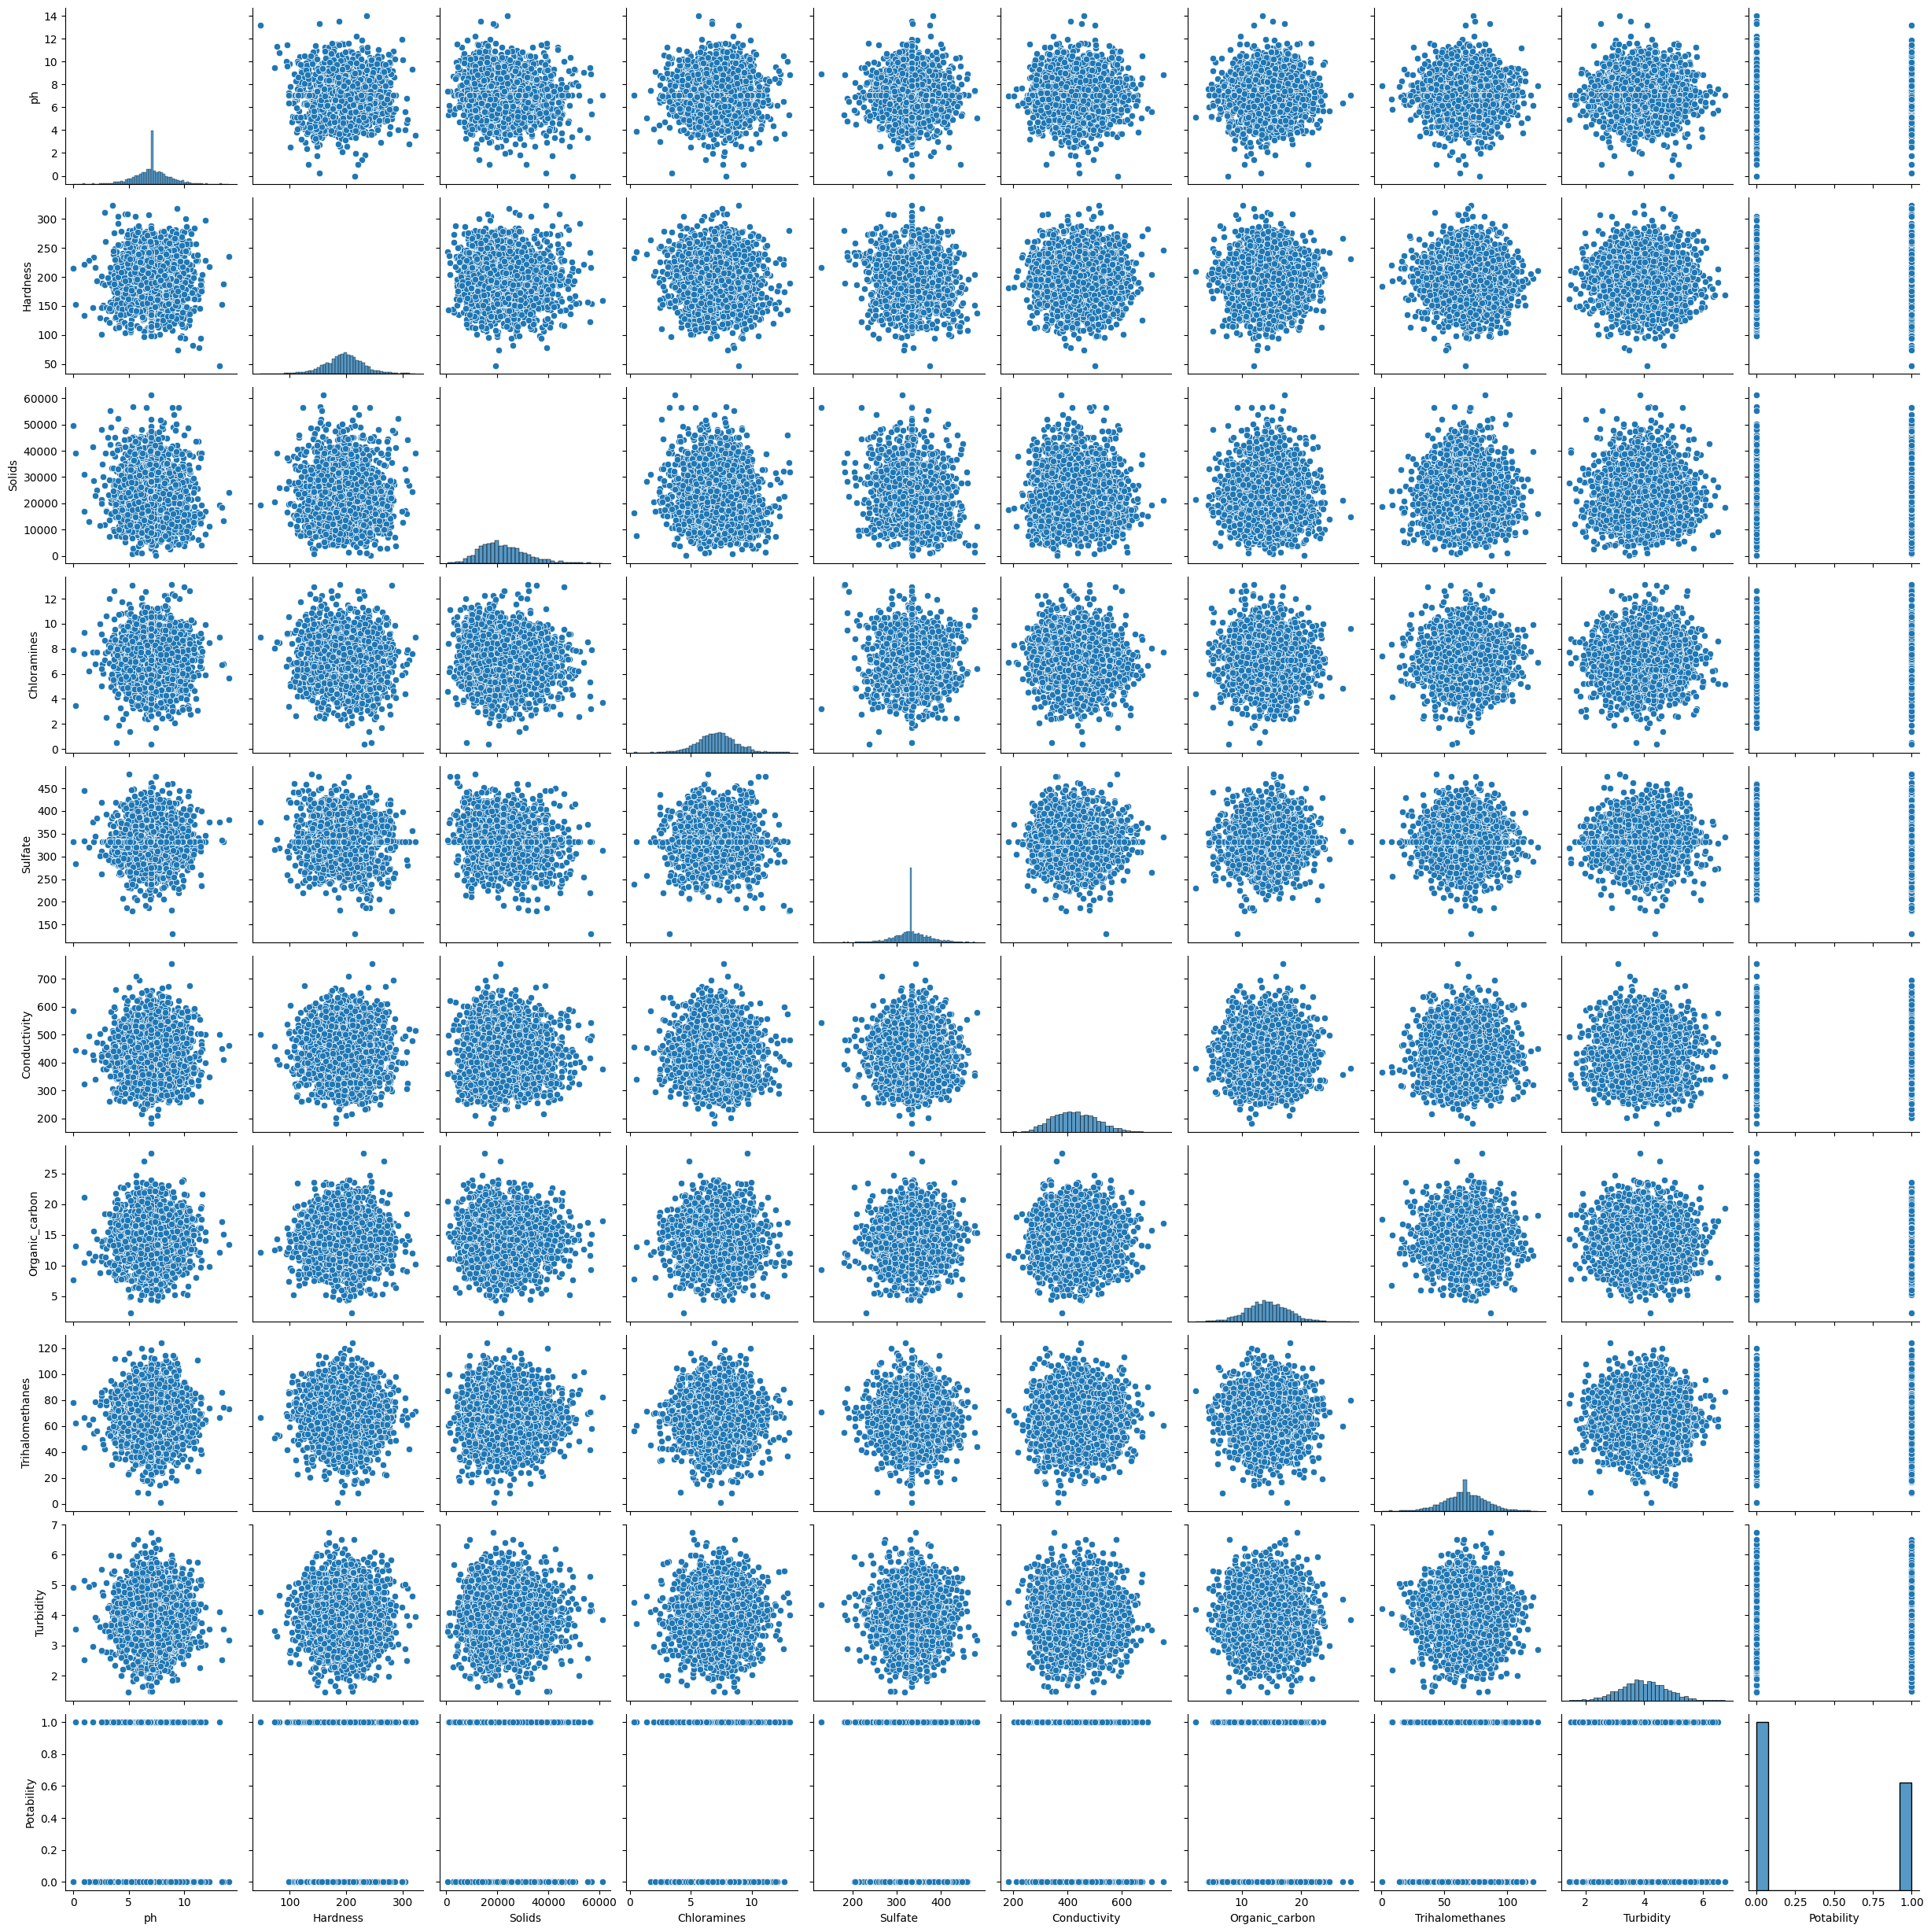

In [92]:
sns.pairplot(df)
plt.show()

## Correlation Analysis

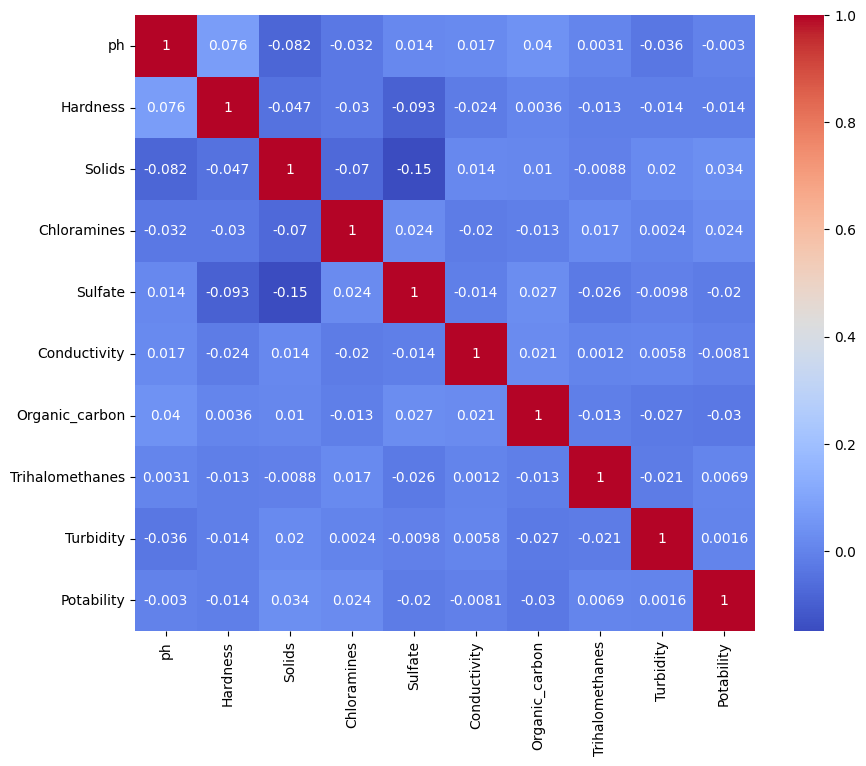

In [118]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

## Splitting data for training and testing

In [120]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=["Potability"])  # Features
y = df["Potability"]  # Target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scalling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (2620, 9)
Testing set size: (656, 9)


## ML Models

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
log_reg = LogisticRegression(max_iter=10000, solver="saga")
rf = RandomForestClassifier(n_estimators=100,class_weight="balanced", random_state=42)
xgb = XGBClassifier(eval_metric="logloss")

# Train models
log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

### Model Evaluation

In [122]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import cross_val_score

# Make predictions
models = {"Logistic Regression": log_reg, "Random Forest": rf, "XGBoost": xgb}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)*100
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"\nModel: {name}")
    print(f"Accuracy:{accuracy:.2f}%")
    print(f"ROC-AUC Score:{roc_auc:.4f}")
    cv_scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"Mean Cross-Validation Accuracy: {np.mean(cv_scores) * 100:.2f}% ± {np.std(cv_scores) * 100:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


Model: Logistic Regression
Accuracy:60.98%
ROC-AUC Score:0.5481
Mean Cross-Validation Accuracy: 60.99% ± 0.07%
Classification Report:
               precision    recall  f1-score   support

           0       0.61      1.00      0.76       400
           1       0.00      0.00      0.00       256

    accuracy                           0.61       656
   macro avg       0.30      0.50      0.38       656
weighted avg       0.37      0.61      0.46       656


Model: Random Forest
Accuracy:66.01%
ROC-AUC Score:0.6552
Mean Cross-Validation Accuracy: 63.55% ± 3.06%
Classification Report:
               precision    recall  f1-score   support

           0       0.66      0.91      0.76       400
           1       0.65      0.28      0.39       256

    accuracy                           0.66       656
   macro avg       0.66      0.59      0.58       656
weighted avg       0.66      0.66      0.62       656


Model: XGBoost
Accuracy:64.79%
ROC-AUC Score:0.6254
Mean Cross-Validation Accur

### Confusion Matrix

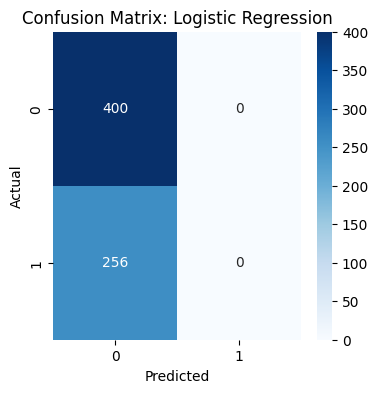

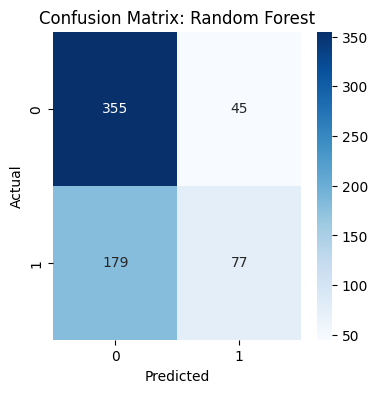

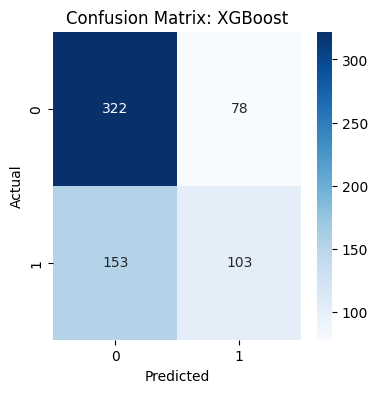

In [98]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix: {name}")
    plt.show()

for name, model in models.items():
    plot_confusion_matrix(model, name)
    print("\n")

### Model Accuracy Comparison

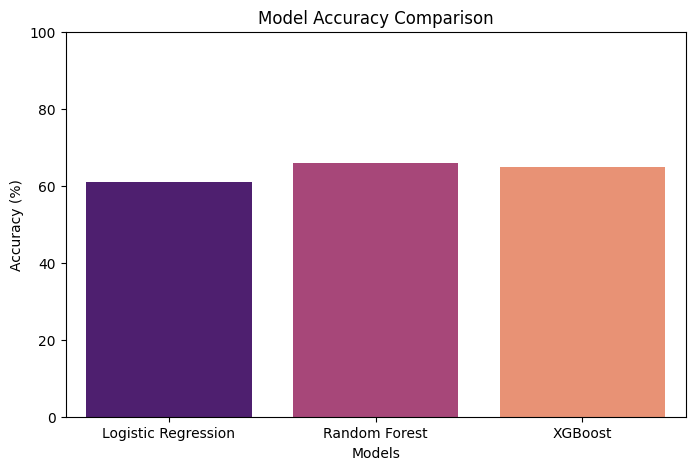

In [115]:
# Define model names and their accuracies
models = ["Logistic Regression", "Random Forest", "XGBoost"]
accuracies = [60.98, 65.85, 64.79]

# Plot the accuracies
plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette="magma", hue=models, legend=False)

# Add labels
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison")
plt.ylim(0, 100)
plt.show()

### Feature Importence

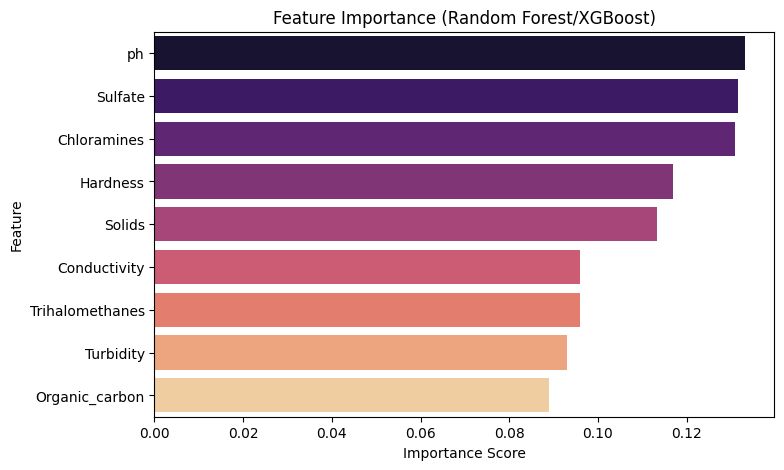

In [119]:
# Get feature importance from the model

feature_importances = model.feature_importances_  # Works for RF/XGBoost
features = X.columns

# Create DataFrame for visualization
feat_imp_df = pd.DataFrame({"Feature": features, "Importance": feature_importances})
feat_imp_df = feat_imp_df.sort_values(by="Importance", ascending=False)

# Plot feature importance
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp_df["Importance"], y=feat_imp_df["Feature"], palette="magma", legend=False, hue=feat_imp_df["Feature"])

# Labels
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest/XGBoost)")
plt.show()